<a href="https://colab.research.google.com/github/EsmeBarker/Collab/blob/main/Copy_of_Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree is kind of like a specific type of flow chart. It has parent and children nodes, and each child can only have one parent. It is a way that your model can think about your data and 'sort' it that is easy to visualize.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth of a decision tree is how many nodes you pass through to get from the starting parent node to the furthest child node(inclusive). If a tree is too deep then it will be overfitting and your model will not do very well with new data.

**Task4:**

How are BART models similar and different from a decision tree?

BART models are like a bunch of decision trees that all work together to create a model better than just one. There's priors that dictate the depth of the decision trees so that they don't get too long and cause overfitting. This allows the BART model to work essentially like a GP, but faster and easier since it isn't just a bunch of polynomials.

**Task5**:

Why would we use a BART model instead of a decision tree?

Because it's really difficult to have a model that works well off of a single decision tree. It's hard for the tree to find unique patterns in the data and overfitting is hard to avoid.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv
!pip install pymc-bart
import pymc_bart as pmb

In [2]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()
penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


In [ ]:
X = penguins["bill_length"].to_numpy().reshape(-1, 1)
Y = penguins["body_mass"].to_numpy()

In [ ]:
X = penguins[["flipper_length", "bill_depth", "bill_length"]].values
y = penguins["body_mass"].values

# Scale X for better model performance
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

with pm.Model() as penguins_model:
    mu = pmb.BART(
        "mu",
        X=X_scaled,
        Y=y,
        m=50
    )
    sigma = pm.HalfNormal("sigma", sigma=1000)
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y)
    idata_penguins = pm.sample(model=penguins_model, compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_penguins,penguins_model, extend_inferencedata=True)


<Axes: xlabel='y'>

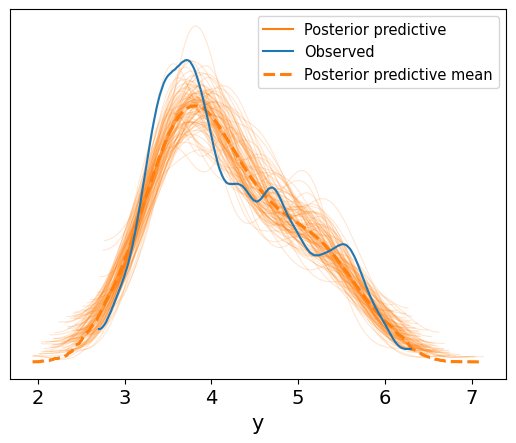

In [5]:
az.plot_ppc(idata_penguins, num_pp_samples=100, colors=["C1", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


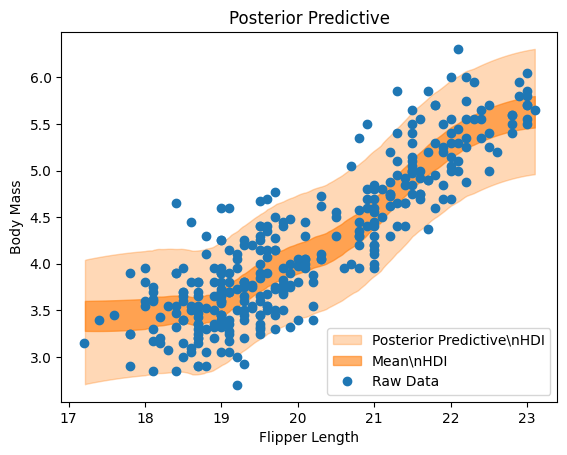

In [ ]:

posterior_mean = idata_penguins.posterior["mu"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["mu"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y"]
).T

idx = np.argsort(X[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive\nHDI"},
)

az.plot_hdi(
    x=X[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean\nHDI"},
)
ax.plot(penguins["flipper_length"], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="Flipper Length",
    ylabel="Body Mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

I think it does an imperfect but pretty good job. It makes sense that as flipper length increases so does body mass(it's literally a part of body mass, and bigger penguin usually equals bigger flipper), and it seems like the model does a good job capturing how that trend looks. It follows the data points fairly well. It doean't do a great job with the lowest data points, but that makes sense because there just aren't very many.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='X_0'>, <Axes: xlabel='X_1'>, <Axes: xlabel='X_2'>],
      dtype=object)

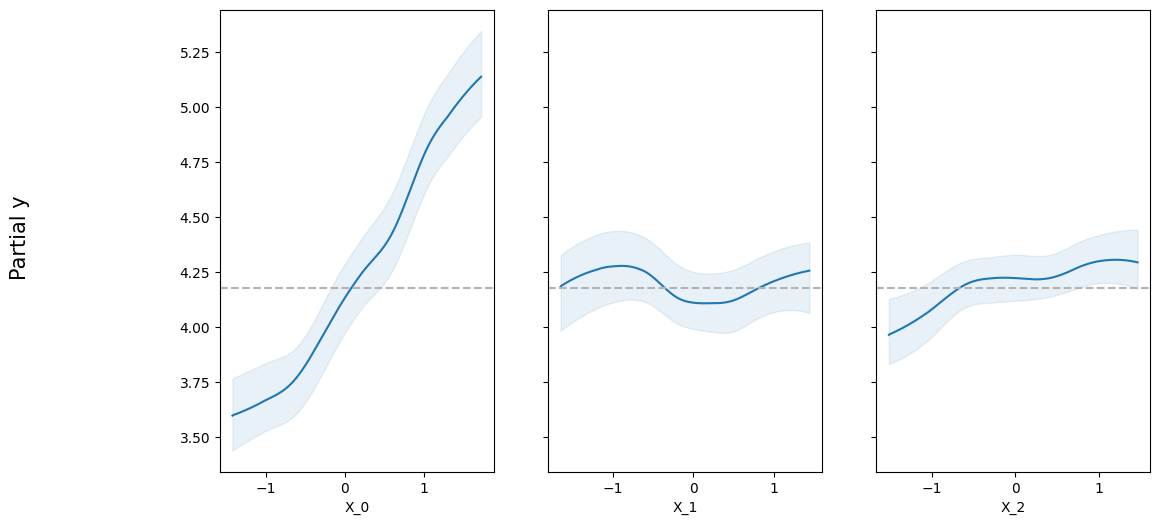

In [ ]:
pmb.plot_pdp(penguins_model.named_vars["mu"], X_scaled, y, var_idx=[0, 1, 2], grid=(1, 3), figsize=(12, 6))

array([<Axes: xlabel='X_0'>, <Axes: xlabel='X_1'>, <Axes: xlabel='X_2'>],
      dtype=object)

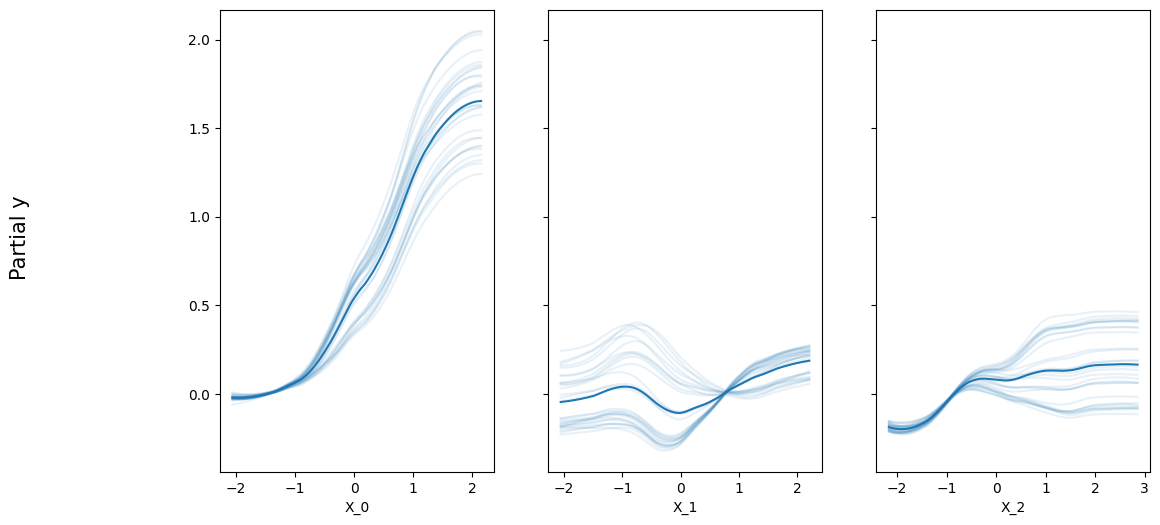

In [ ]:
pmb.plot_ice(penguins_model.named_vars["mu"], X_scaled, y, var_idx=[0, 1, 2], grid=(1, 3), figsize=(12, 6))

<Axes: ylabel='R²'>

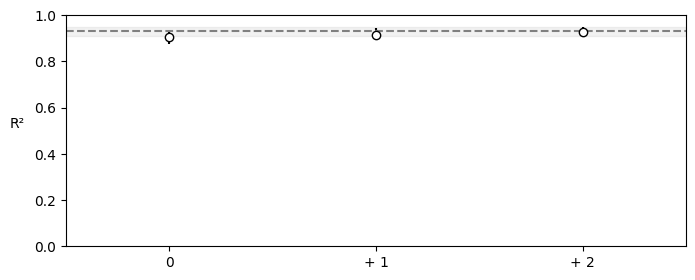

In [ ]:
vi = pmb.compute_variable_importance(idata_penguins, penguins_model.named_vars["mu"], X_scaled)
pmb.plot_variable_importance(vi)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

All of the variables work pretty well, but flipper length looks the most important based on the ice plot. Bill length seems like it is probably the second most important, but there is a lot of variance in the larger values. Flipper length seems like it is predicting well for the mid range, but that much for smaller penguins. They all definitely have a positive correlation with body mass, but are also probably affecting each other. There is definitely an interaction between bill depth and length, for example, because larger bills will probably just have greater values for both of these things. Their plots look pretty similar, at least compared to how different the flipper length plot is.